In [1]:
import requests

# Get series information for KXHIGHNY
url = "https://api.elections.kalshi.com/trade-api/v2/series/KXECONSTATCORECPIYOY"
response = requests.get(url)
series_data = response.json()

# Check if 'series' key exists before accessing its values
if 'series' in series_data:
    print(f"Series Title: {series_data['series']['title']}")
    print(f"Frequency: {series_data['series']['frequency']}")
    print(f"Category: {series_data['series']['category']}")
else:
    print(f"Error fetching series data: {series_data.get('error', 'Unknown error')}")
print(series_data)

Series Title: year over year core inflation
Frequency: custom
Category: Economics
{'series': {'additional_prohibitions': ['Persons who are employed by any of the Source Agencies are not permitted to trade on the Contract.', 'Persons who hold any material, non-public information on the Underlying are not permitted to trade on the Contract.'], 'category': 'Economics', 'contract_terms_url': 'https://kalshi-public-docs.s3.amazonaws.com/contract_terms/ECONSTAT.pdf', 'contract_url': 'https://kalshi-public-docs.s3.us-east-1.amazonaws.com/regulatory/product-certifications/ECONSTAT.pdf', 'fee_multiplier': 1, 'fee_type': 'quadratic', 'frequency': 'custom', 'last_updated_ts': '2026-03-24T01:28:25.727552Z', 'product_metadata': {'important_info': None}, 'settlement_sources': [{'name': 'Bureau of Labor Statistics- Consumer Price Index', 'url': 'https://www.bls.gov/news.release/cpi.nr0.htm'}, {'name': 'Bureau of Labor Statistics- Employment Situation', 'url': 'https://www.bls.gov/news.release/empsit.

In [31]:
# Get all markets for the KXECONSTATCORECPIYOY series (removing the status filter)
markets_url = f"https://api.elections.kalshi.com/trade-api/v2/markets?series_ticker=KXECONSTATCORECPIYOY"
markets_response = requests.get(markets_url)
markets_data = markets_response.json()

print(f"\nActive markets in KXECONSTATCORECPIYOY series:")
for market in markets_data['markets']:
    print(f"- {market['ticker']}: {market['title']}")
    print(f"  Event: {market['event_ticker']}")
    # Use .get() to safely access 'yes_price' and 'volume', providing 'N/A' if not present
    yes_price_display = f"{market.get('yes_price', 'N/A')}¢" if market.get('yes_price') is not None else 'N/A'
    volume_display = market.get('volume', 'N/A')
    print(f"  Yes Price: {yes_price_display} | Volume: {volume_display}")
    print()

# Get details for a specific event if you have its ticker
if markets_data['markets']:
    # Let's get details for the first market's event
    event_ticker = markets_data['markets'][0]['event_ticker']
    event_url = f"https://api.elections.kalshi.com/trade-api/v2/events/{event_ticker}"
    event_response = requests.get(event_url)
    event_data = event_response.json()

    print(f"Event Details:")
    print(f"Title: {event_data['event']['title']}")
    print(f"Category: {event_data['event']['category']}")


Active markets in KXHIGHNY series:
- KXECONSTATCORECPIYOY-26NOV-T3.7: CPI core year-over-year in Nov 2026?
  Event: KXECONSTATCORECPIYOY-26NOV
  Yes Price: N/A | Volume: 0

- KXECONSTATCORECPIYOY-26NOV-T3.6: CPI core year-over-year in Nov 2026?
  Event: KXECONSTATCORECPIYOY-26NOV
  Yes Price: N/A | Volume: 0

- KXECONSTATCORECPIYOY-26NOV-T3.5: CPI core year-over-year in Nov 2026?
  Event: KXECONSTATCORECPIYOY-26NOV
  Yes Price: N/A | Volume: 0

- KXECONSTATCORECPIYOY-26NOV-T3.4: CPI core year-over-year in Nov 2026?
  Event: KXECONSTATCORECPIYOY-26NOV
  Yes Price: N/A | Volume: 0

- KXECONSTATCORECPIYOY-26NOV-T3.3: CPI core year-over-year in Nov 2026?
  Event: KXECONSTATCORECPIYOY-26NOV
  Yes Price: N/A | Volume: 0

- KXECONSTATCORECPIYOY-26NOV-T3.2: CPI core year-over-year in Nov 2026?
  Event: KXECONSTATCORECPIYOY-26NOV
  Yes Price: N/A | Volume: 0

- KXECONSTATCORECPIYOY-26NOV-T3.1: CPI core year-over-year in Nov 2026?
  Event: KXECONSTATCORECPIYOY-26NOV
  Yes Price: N/A | Volume: 0

In [37]:
# Get orderbook for all markets in the KXECONSTATCORECPIYOY series

if not markets_data['markets']:
    print("No markets found for the KXECONSTATCORECPIYOY series. Please ensure the series ticker is correct and markets exist.")
else:
    for market in markets_data['markets']:
        market_ticker = market['ticker']
        market_title = market['title'] # Get the market title

        # Safely get the expected CPI core percentage if available
        expected_cpi_core = market.get('custom_strike', {}).get('Value', 'N/A')

        orderbook_url = f"https://api.elections.kalshi.com/trade-api/v2/markets/{market_ticker}/orderbook"

        orderbook_response = requests.get(orderbook_url)
        orderbook_data = orderbook_response.json()

        print(f"\n--- Orderbook for {market_ticker} ---")
        print(f"Market Title: {market_title}")
        print(f"Expected CPI Core: {expected_cpi_core}%") # Print the expected CPI core

        print("YES BIDS:")
        if 'yes' in orderbook_data['orderbook'] and orderbook_data['orderbook']['yes']:
            for bid in orderbook_data['orderbook']['yes'][:5]:  # Show top 5
                print(f"  Price: {bid[0]}¢, Quantity: {bid[1]}")
        else:
            print("  No YES bids available.")

        print("\nNO BIDS:")
        if 'no' in orderbook_data['orderbook'] and orderbook_data['orderbook']['no']:
            for bid in orderbook_data['orderbook']['no'][:5]:  # Show top 5
                print(f"  Price: {bid[0]}¢, Quantity: {bid[1]}")
        else:
            print("  No NO bids available.")
        print("-------------------------------------")


--- Orderbook for KXECONSTATCORECPIYOY-26NOV-T3.7 ---
Market Title: CPI core year-over-year in Nov 2026?
Expected CPI Core: 3.7%
YES BIDS:
  No YES bids available.

NO BIDS:
  Price: 11¢, Quantity: 5000
  Price: 95¢, Quantity: 200
-------------------------------------

--- Orderbook for KXECONSTATCORECPIYOY-26NOV-T3.6 ---
Market Title: CPI core year-over-year in Nov 2026?
Expected CPI Core: 3.6%
YES BIDS:
  No YES bids available.

NO BIDS:
  Price: 10¢, Quantity: 5000
  Price: 95¢, Quantity: 200
-------------------------------------

--- Orderbook for KXECONSTATCORECPIYOY-26NOV-T3.5 ---
Market Title: CPI core year-over-year in Nov 2026?
Expected CPI Core: 3.5%
YES BIDS:
  No YES bids available.

NO BIDS:
  Price: 11¢, Quantity: 4921
  Price: 94¢, Quantity: 200
-------------------------------------

--- Orderbook for KXECONSTATCORECPIYOY-26NOV-T3.4 ---
Market Title: CPI core year-over-year in Nov 2026?
Expected CPI Core: 3.4%
YES BIDS:
  No YES bids available.

NO BIDS:
  Price: 10¢, Q

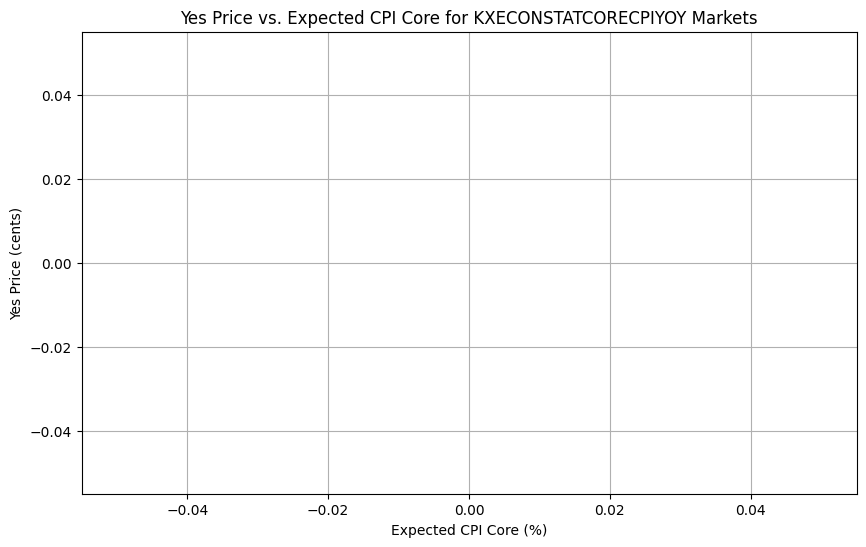

In [38]:
# Genereer een grafiek van YES Price versus Expected CPI Core
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
cpi_core_predictions = []
market_yes_prices = []

for market in markets_data['markets']:
    expected_cpi_core = market.get('custom_strike', {}).get('Value')
    yes_price = market.get('yes_price')

    # Only include markets where both values are available and are numeric
    if expected_cpi_core is not None and yes_price is not None:
        try:
            cpi_core_predictions.append(float(expected_cpi_core))
            market_yes_prices.append(float(yes_price))
        except ValueError: # Handle cases where conversion to float fails
            continue

# Create a DataFrame for plotting
df_cpi_prices = pd.DataFrame({
    'Expected CPI Core': cpi_core_predictions,
    'Yes Price': market_yes_prices
})

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Expected CPI Core', y='Yes Price', data=df_cpi_prices)
plt.title('Yes Price vs. Expected CPI Core for KXECONSTATCORECPIYOY Markets')
plt.xlabel('Expected CPI Core (%)')
plt.ylabel('Yes Price (cents)')
plt.grid(True)
plt.show()

# Task
Push the local changes made to the "Kalshi_economics" repository to GitHub.

## Clone Repository

### Subtask:
Kloon de GitHub-repository 'https://github.com/hunsec/Kalshi_economics.git' naar de huidige Colab-omgeving. Dit zal een lokale kopie van de repository aanmaken.


**Reasoning**:
To clone the specified GitHub repository into the Colab environment, I will use the `!git clone` command in a code cell.



In [41]:
!git clone https://github.com/hunsec/Kalshi_economics.git
print("Repository cloned successfully.")

fatal: destination path 'Kalshi_economics' already exists and is not an empty directory.
Repository cloned successfully.
